In [1]:
import numpy as np
import pandas as pd
import pygimli as pg
from pygimli.physics import ert
import matplotlib.pyplot as plt
import glob
import os
import matplotlib.patheffects as PathEffects


In [2]:
# figure plotting preferences 

dpi = 200 # resolution
fs = 20 # fontsize

In [3]:
# copy threshold values from profile with borehole

y_th_ches = np.array(
[928.6718396770394,
 861.3603045754148,
 890.7930701023323,
 581.3586627258763,
 826.4875657317602,
 869.3582555633365,
 900.9042717431744]
)

In [4]:
# range of inversion parameters to test 

lam = np.array([1,3,9,
               3,3,
               3,3])

mstart_mult = np.array([1,1,1,
                  1,1,
                  0.1,10])

err_rel = np.array([0.03,0.03,0.03,
                    0.015,0.06,
                    0.03,0.03])    

In [5]:

def invert_w_sensitivity(pn,fn,sensorids,yth,lam,mstart_mult,err_rel):
    
    T_plt_all = []
    R_plt_all = []
    p_f_all = []
    p_uf_all = []
    xth_all = []
    yth_all = []
    contours = []
    
    for j in range(0,len(lam)):
        
        contours_temp = []
        # load raw fata

        data_raw = ert.load(pn+fn) 

        survey_name=fn
        plotmodel=True

        # calculate geometric factor and apparent resistivity if not already in data file

        if data_raw.haveData('k')==False:
            data_raw['k'] = ert.createGeometricFactors(data_raw,numerical=True) # include topo in k calculation

        if data_raw.haveData('rhoa')==False:
            if data_raw.haveData('r')==False:
                data_raw['r'] = data_raw['u']/data_raw['i']
            data_raw['rhoa'] = data_raw['r']*data_raw['k'] 

        # some datasets had problematic cables. if so, remove those data points

        if sensorids is not None:
            data_raw.removeSensorIdx(sensorids)

        mgr = ert.ERTManager(data_raw)

        # inversion parameters

        mgr.inv.inv.setBlockyModel(True)

        data_raw['err'] = ert.estimateError(
        data_raw, 
        absoluteError=0.001, 
        relativeError=err_rel[j] # % noise
        )

        # run inversion

        mod = mgr.invert(
            data_raw,
            lam=lam[j],
            startModel=np.mean(data_raw['rhoa'])*mstart_mult[j],
        )

        # getting chi2, rms error

        chi2 = mgr.inv.inv.getChi2()
        rms = np.sqrt(np.mean(((data_raw['rhoa']-mgr.inv.response)/data_raw['rhoa'])**2))*100

        # plot results

        fig1, ax1 = plt.subplots(1,1,figsize=[13,5])

        ax, cBar = mgr.showResult(
           mod,
            ax=ax1,
            cMap='turbo_r',
            coverage=mgr.coverage(),
            cMin=100,
            cMax=15000,
            orientation='vertical',
        )

        # colorbar

        cBar.set_label('')
        cBar.ax.tick_params(labelsize=fs-4) 
        cBar.ax.set_title(r'$\rho$ ($\Omega$m)'+ '\n',fontsize=fs,rotation=270, y=0.35,x=5)

        # get axis limits and trim figure automatically

        Ex = np.array(data_raw.sensors()).T[0]
        Ey = np.array(data_raw.sensors()).T[1]
        xmin = min(Ex)
        xmax = max(Ex)
        ymin = mgr.paraDomain.yMin()
        ymax = mgr.paraDomain.yMax()
        trim_ymin = ymin + (ymax-ymin)/3
        ax1.set_ylim([trim_ymin,ymax+abs(ymax-ymin)*0.07])
        ax1.set_xlim([xmin,xmax])

        # figure details - electrodes, rms error, axis labels, borehole location

#         ax1.plot(Ex,Ey,'ko')
        txt = ax1.text(xmin+(xmax-xmin)*0.02,trim_ymin+(ymax-trim_ymin)*0.1,'RMSE=%.1f%%'%(rms),color='k',fontsize=fs)
        ax1.tick_params(axis='both', labelsize=fs-4)
        ax1.set_xlabel('X (m)',fontsize=fs)
        ax1.set_ylabel('Z (m)',fontsize=fs)
        
        if j==1: # best estimate model
            
            cs = ax1.tricontour(
                np.array(mgr.paraDomain.cellCenters()).T[0],
                np.array(mgr.paraDomain.cellCenters()).T[1],
                mgr.model,
                levels=[yth[j]],
                colors='k',
                linewidth=3,
                alpha=1,
                zorder=3          
                  )   

        else: # sensitivity analyis results

            cs = ax1.tricontour(
                np.array(mgr.paraDomain.cellCenters()).T[0],
                np.array(mgr.paraDomain.cellCenters()).T[1],
                mgr.model,
                levels=[yth[j]],
                colors='blueviolet',
                linewidth=3,
                alpha=1,
                  ) 

        for collection in cs.collections:
            for path in collection.get_paths():
                contours_temp.append(path.vertices.copy())      

        contours.append(contours_temp)
        
        plt.show()     
    return contours

10/04/26 - 12:47:47 - pyGIMLi - INFO - Cache /Users/teddiherringnew/opt/miniconda3/envs/idgsp-mc/lib/python3.9/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (1.8s x 41): /Users/teddiherringnew/Library/Caches/pygimli/3295802236228985221
10/04/26 - 12:47:47 - pyGIMLi - INFO - Found 2 regions.
10/04/26 - 12:47:47 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/04/26 - 12:47:47 - Core - WARNING - Region Nr: 1  is background and should not get a model transformation.
10/04/26 - 12:47:47 - Core - WARNING - Region Nr: 1  is background and should not get a model control.
10/04/26 - 12:47:47 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/04/26 - 12:47:47 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/04/26 - 12:47:47 - pyGIMLi - INFO - Homogeneous starting model set to: 384.11857156459337


/var/folders/5z/g4c125y952l233l_4lb9yt6c0000gp/T/ipykernel_21044/2620157793.py:116: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cs = ax1.tricontour(


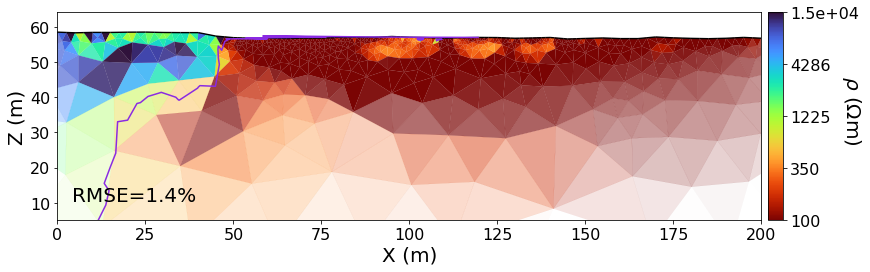

10/04/26 - 12:47:56 - pyGIMLi - INFO - Cache /Users/teddiherringnew/opt/miniconda3/envs/idgsp-mc/lib/python3.9/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (1.8s x 42): /Users/teddiherringnew/Library/Caches/pygimli/3295802236228985221
10/04/26 - 12:47:56 - pyGIMLi - INFO - Found 2 regions.
10/04/26 - 12:47:56 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/04/26 - 12:47:56 - Core - WARNING - Region Nr: 1  is background and should not get a model transformation.
10/04/26 - 12:47:56 - Core - WARNING - Region Nr: 1  is background and should not get a model control.
10/04/26 - 12:47:56 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/04/26 - 12:47:56 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/04/26 - 12:47:56 - pyGIMLi - INFO - Homogeneous starting model set to: 384.11857156459337


/var/folders/5z/g4c125y952l233l_4lb9yt6c0000gp/T/ipykernel_21044/2620157793.py:103: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cs = ax1.tricontour(


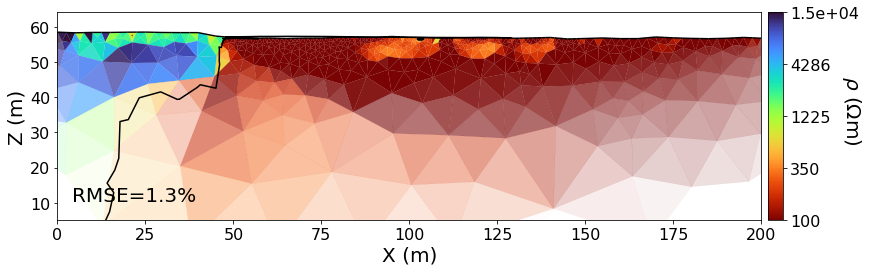

10/04/26 - 12:48:02 - pyGIMLi - INFO - Cache /Users/teddiherringnew/opt/miniconda3/envs/idgsp-mc/lib/python3.9/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (1.8s x 43): /Users/teddiherringnew/Library/Caches/pygimli/3295802236228985221
10/04/26 - 12:48:02 - pyGIMLi - INFO - Found 2 regions.
10/04/26 - 12:48:02 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/04/26 - 12:48:02 - Core - WARNING - Region Nr: 1  is background and should not get a model transformation.
10/04/26 - 12:48:02 - Core - WARNING - Region Nr: 1  is background and should not get a model control.
10/04/26 - 12:48:02 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/04/26 - 12:48:02 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/04/26 - 12:48:02 - pyGIMLi - INFO - Homogeneous starting model set to: 384.11857156459337


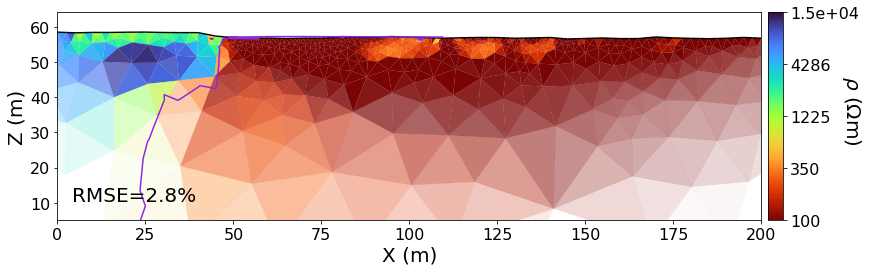

10/04/26 - 12:48:08 - pyGIMLi - INFO - Cache /Users/teddiherringnew/opt/miniconda3/envs/idgsp-mc/lib/python3.9/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (1.8s x 44): /Users/teddiherringnew/Library/Caches/pygimli/3295802236228985221
10/04/26 - 12:48:08 - pyGIMLi - INFO - Found 2 regions.
10/04/26 - 12:48:08 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/04/26 - 12:48:08 - Core - WARNING - Region Nr: 1  is background and should not get a model transformation.
10/04/26 - 12:48:08 - Core - WARNING - Region Nr: 1  is background and should not get a model control.
10/04/26 - 12:48:08 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/04/26 - 12:48:08 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/04/26 - 12:48:08 - pyGIMLi - INFO - Homogeneous starting model set to: 384.11857156459337


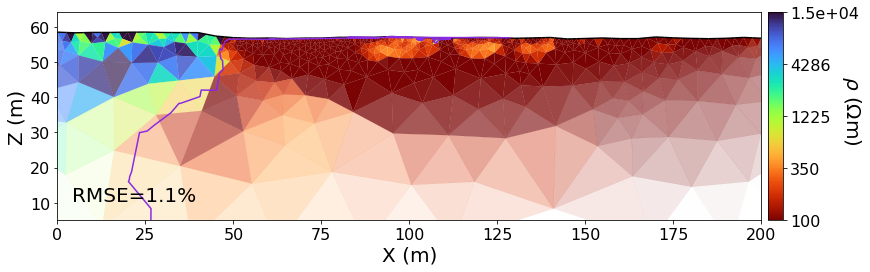

10/04/26 - 12:48:16 - pyGIMLi - INFO - Cache /Users/teddiherringnew/opt/miniconda3/envs/idgsp-mc/lib/python3.9/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (1.8s x 45): /Users/teddiherringnew/Library/Caches/pygimli/3295802236228985221
10/04/26 - 12:48:16 - pyGIMLi - INFO - Found 2 regions.
10/04/26 - 12:48:16 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/04/26 - 12:48:16 - Core - WARNING - Region Nr: 1  is background and should not get a model transformation.
10/04/26 - 12:48:16 - Core - WARNING - Region Nr: 1  is background and should not get a model control.
10/04/26 - 12:48:16 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/04/26 - 12:48:16 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/04/26 - 12:48:16 - pyGIMLi - INFO - Homogeneous starting model set to: 384.11857156459337


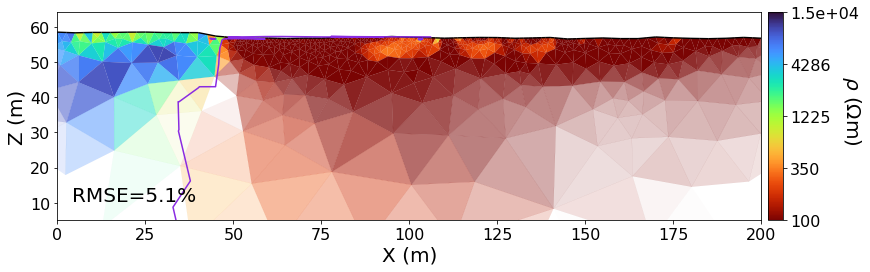

10/04/26 - 12:48:21 - pyGIMLi - INFO - Cache /Users/teddiherringnew/opt/miniconda3/envs/idgsp-mc/lib/python3.9/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (1.8s x 46): /Users/teddiherringnew/Library/Caches/pygimli/3295802236228985221
10/04/26 - 12:48:21 - pyGIMLi - INFO - Found 2 regions.
10/04/26 - 12:48:21 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/04/26 - 12:48:21 - Core - WARNING - Region Nr: 1  is background and should not get a model transformation.
10/04/26 - 12:48:21 - Core - WARNING - Region Nr: 1  is background and should not get a model control.
10/04/26 - 12:48:21 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/04/26 - 12:48:21 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/04/26 - 12:48:21 - pyGIMLi - INFO - Homogeneous starting model set to: 38.41185715645934


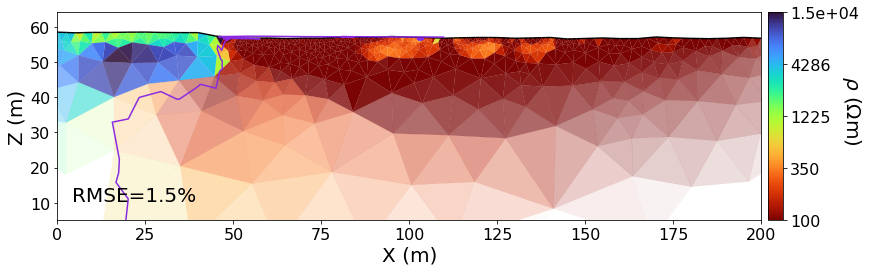

10/04/26 - 12:48:27 - pyGIMLi - INFO - Cache /Users/teddiherringnew/opt/miniconda3/envs/idgsp-mc/lib/python3.9/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (1.8s x 47): /Users/teddiherringnew/Library/Caches/pygimli/3295802236228985221
10/04/26 - 12:48:27 - pyGIMLi - INFO - Found 2 regions.
10/04/26 - 12:48:27 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/04/26 - 12:48:27 - Core - WARNING - Region Nr: 1  is background and should not get a model transformation.
10/04/26 - 12:48:27 - Core - WARNING - Region Nr: 1  is background and should not get a model control.
10/04/26 - 12:48:27 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/04/26 - 12:48:27 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/04/26 - 12:48:28 - pyGIMLi - INFO - Homogeneous starting model set to: 3841.1857156459337


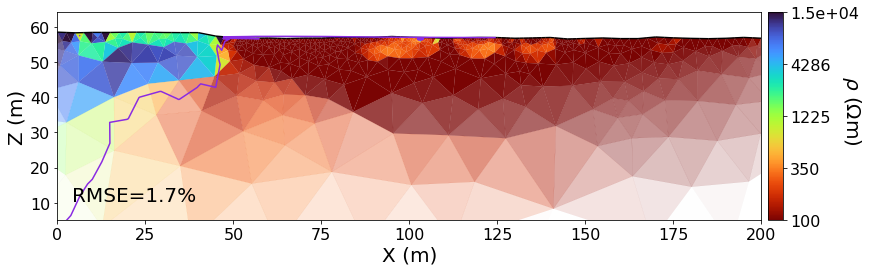

In [6]:

contours_ches = invert_w_sensitivity(
    pn = '../formatted ert data/summer 2023/',
    fn = '20230901 CHES W200.txt',
    sensorids = None,
    yth=y_th_ches,
    lam=lam,
    mstart_mult=mstart_mult,
    err_rel=err_rel
)

In [7]:
# get best estimate model

j=1 

pn = '../formatted ert data/summer 2023/'
fn = '20230901 CHES W200.txt'
sensorids = None

data_raw = ert.load(pn+fn) 

# calculate geometric factor and apparent resistivity if not already in data file

if data_raw.haveData('k')==False:
    data_raw['k'] = ert.createGeometricFactors(data_raw,numerical=True) # include topo in k calculation

if data_raw.haveData('rhoa')==False:
    if data_raw.haveData('r')==False:
        data_raw['r'] = data_raw['u']/data_raw['i']
    data_raw['rhoa'] = data_raw['r']*data_raw['k'] 

# some datasets had problematic cables. if so, remove those data points

if sensorids is not None:
    data_raw.removeSensorIdx(sensorids)

mgr = ert.ERTManager(data_raw)

# inversion parameters

mgr.inv.inv.setBlockyModel(True)

data_raw['err'] = ert.estimateError(
data_raw, 
absoluteError=0.001, 
relativeError=err_rel[j] # % noise
)

# run inversion

mod = mgr.invert(
    data_raw,
    lam=lam[j],
    startModel=np.mean(data_raw['rhoa'])*mstart_mult[j],
)

# getting chi2, rms error

chi2 = mgr.inv.inv.getChi2()
rms = np.sqrt(np.mean(((data_raw['rhoa']-mgr.inv.response)/data_raw['rhoa'])**2))*100



10/04/26 - 12:48:34 - pyGIMLi - INFO - Cache /Users/teddiherringnew/opt/miniconda3/envs/idgsp-mc/lib/python3.9/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (1.8s x 48): /Users/teddiherringnew/Library/Caches/pygimli/3295802236228985221
10/04/26 - 12:48:34 - pyGIMLi - INFO - Found 2 regions.
10/04/26 - 12:48:34 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/04/26 - 12:48:34 - Core - WARNING - Region Nr: 1  is background and should not get a model transformation.
10/04/26 - 12:48:34 - Core - WARNING - Region Nr: 1  is background and should not get a model control.
10/04/26 - 12:48:34 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/04/26 - 12:48:34 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/04/26 - 12:48:34 - pyGIMLi - INFO - Homogeneous starting model set to: 384.11857156459337


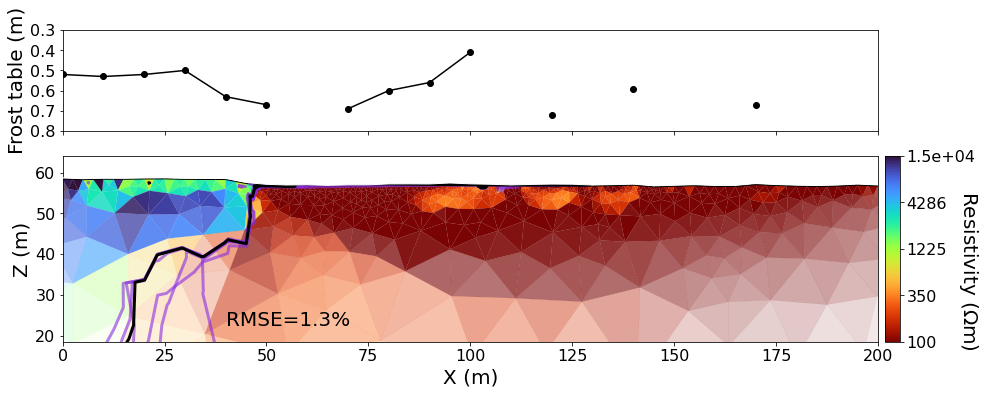

In [8]:
# plot ensemble interpretation

fig1, ax1 = plt.subplots(1,1,figsize=[15,5])

ax, cBar = mgr.showResult(
   mod,
    ax=ax1,
    cMap='turbo_r',
    coverage=mgr.coverage(),
    cMin=100,
    cMax=15000,
    orientation='vertical',
)

# colorbar

cBar.set_label('')
cBar.ax.tick_params(labelsize=fs-4) 
cBar.ax.set_title(r'Resistivity ($\Omega$m)'+ '\n',fontsize=fs,rotation=270, y=-0.06,x=5)

# get axis limits and trim figure automatically

Ex = np.array(data_raw.sensors()).T[0]
Ey = np.array(data_raw.sensors()).T[1]
xmin = min(Ex)
xmax = max(Ex)
ymin = mgr.paraDomain.yMin()
ymax = mgr.paraDomain.yMax()
trim_ymin = ymin + (ymax-ymin)/2
ax1.set_ylim([trim_ymin,ymax+abs(ymax-ymin)*0.07])
ax1.set_xlim([xmin,xmax])

# figure details - electrodes, rms error, axis labels, borehole location

# ax1.plot(Ex,Ey,'ko')
txt = ax1.text(xmin+(xmax-xmin)*0.2,trim_ymin+(ymax-trim_ymin)*0.1,'RMSE=%.1f%%'%(rms),color='k',fontsize=fs)
ax1.tick_params(axis='both', labelsize=fs-4)
ax1.set_xlabel('X (m)',fontsize=fs)
ax1.set_ylabel('Z (m)',fontsize=fs)

# plot frozen/unfrozen interface 

for i in range(len(contours_ches)):
    for j in range(len(contours_ches[i])):
        if i ==1:
            ax1.plot(contours_ches[i][j][:, 0],contours_ches[i][j][:, 1], color='k',linestyle='-',linewidth=3,alpha=1,zorder=3)
        else:
            ax1.plot(contours_ches[i][j][:, 0],contours_ches[i][j][:, 1], color='blueviolet',linestyle='-',linewidth=3,alpha=0.6,zorder=2)

# add white patch to hide where countour lines are interpolated above ground surface
  
xt = np.hstack([10,Ex,400])
yt = np.hstack([60,Ey+0.2,60])
from matplotlib.patches import Polygon

P= Polygon(np.array([xt,yt]).T, facecolor = 'w',edgecolor='w',linewidth=1,zorder=4) 
ax1.add_patch(P)

# plot frost table

frost_table = pd.read_excel('/Users/teddiherringnew/Desktop/HBR_ERT_JGR/frost tables/20230901 CHES 200.xlsx')   
ft_x = np.array(frost_table['x'])
topo_x = np.array(data_raw.sensors()).T[0]

ft_z = np.array(frost_table['z'])
topo_z = np.array(data_raw.sensors()).T[1]

ft_z = np.where(ft_z==0, np.nan, ft_z) 

ax1 = fig1.add_axes([0.125,0.83,0.755,0.28])
[x,i1,i2] = np.intersect1d(ft_x,topo_x,return_indices=True)
ax1.plot(ft_x,ft_z/100,'ko-')
ax1.set_ylabel('Frost table (m)',fontsize=fs)
plt.gca().invert_yaxis()
ax1.set_xlim([xmin,xmax])
ax1.tick_params(axis='both', labelsize=fs-4)
ax1.tick_params(labelbottom=False)    
ax1.set_ylim([0.8,0.3])
ax1.set_yticks(np.arange(0.3,.81,step=0.1)) 

fig1.savefig('../inverted results/c1.png',format='png',dpi=dpi,bbox_inches='tight',facecolor='w')


lower depths
17.449529368650488
280.29731983342907

shallower depths, left lake 
25.193722680840505
134.6603563810222

shallower depths, middle lake 
27.797414868197794
2526.614452903406
188.5147671317404

[  27.79741487   30.83302884   31.13617451   41.81431721   41.86283021
   43.99067173   44.56654473   45.78334254   47.28830534   50.74616166
   51.2028831    52.22793818   57.97996101   58.60976581   59.35947924
   59.57280017   59.77607837   60.36618754   61.44841988   63.95945093
   64.04974165   65.35397709   65.93708145   66.16043029   67.40152594
   69.02829754   71.6890041    71.8525288    72.30444059   74.02127849
   75.60874064   76.2268607    76.52595905   77.19245439   77.7893326
   77.85184567   78.18558726   78.31897262   78.85400187   79.0057568
   80.72077028   81.14116327   82.31985811   83.42327256   84.26287362
   85.09752387   85.39579014   89.83513017   91.82735324   91.9012491
   92.57680037   92.74256953   94.34299903   96.54393182   97.25311539
   97.74604726  

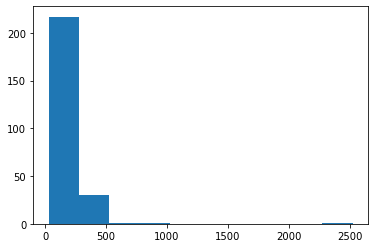

In [9]:
# ches lake

I1 = np.logical_and(
    np.array(mgr.paraDomain.cellCenters()).T[0]>50,
    np.array(mgr.paraDomain.cellCenters()).T[0]<200,
)

I2 = np.logical_and(
    np.array(mgr.paraDomain.cellCenters()).T[1]<50,
    np.array(mgr.paraDomain.cellCenters()).T[1]>30
)

I3 = np.logical_and(I1,I2)

print('lower depths')
print(min(np.array(mod)[I3]))
print(max(np.array(mod)[I3]))
print('')


# ches lake

I1 = np.logical_and(
    np.array(mgr.paraDomain.cellCenters()).T[0]>50,
    np.array(mgr.paraDomain.cellCenters()).T[0]<85,
)

I2 = np.logical_and(
    np.array(mgr.paraDomain.cellCenters()).T[1]<60,
    np.array(mgr.paraDomain.cellCenters()).T[1]>50
)

I3 = np.logical_and(I1,I2)

print('shallower depths, left lake ')
print(min(np.array(mod)[I3]))
print(max(np.array(mod)[I3]))
print('')

# ches lake

I1 = np.logical_and(
    np.array(mgr.paraDomain.cellCenters()).T[0]>85,
    np.array(mgr.paraDomain.cellCenters()).T[0]<145,
)

I2 = np.logical_and(
    np.array(mgr.paraDomain.cellCenters()).T[1]<60,
    np.array(mgr.paraDomain.cellCenters()).T[1]>50
)

I3 = np.logical_and(I1,I2)

print('shallower depths, middle lake ')
print(min(np.array(mod)[I3]))
print(max(np.array(mod)[I3]))
print(np.mean(np.array(mod)[I3]))
print('')
plt.hist(np.array(mod)[I3])
print(np.sort(np.array(mod)[I3]))
# ches lake

I1 = np.logical_and(
    np.array(mgr.paraDomain.cellCenters()).T[0]>145,
    np.array(mgr.paraDomain.cellCenters()).T[0]<200,
)

I2 = np.logical_and(
    np.array(mgr.paraDomain.cellCenters()).T[1]<60,
    np.array(mgr.paraDomain.cellCenters()).T[1]>50
)

I3 = np.logical_and(I1,I2)

print('shallower depths, right lake')
print(min(np.array(mod)[I3]))
print(max(np.array(mod)[I3]))
print('')

